# Notebook 3 — YOLO11 + OC-SORT on all three custom clips

This notebook compares two tracking modes on **clip1**, **clip2**, and
**continuous**:

1. **Baseline:** pretrained YOLO11n person detections → OC-SORT.
2. **Improved:** the exact same cached YOLO11n detections → OC-SORT, with
   hard-cut detection, motion-state reset, and selective OSNet identity recovery.

There is **no training or fine-tuning**. Everything runs on CPU. Each detector
cache is shared by both modes, so the tracker comparison is controlled.

> These custom clips have no identity ground truth. Therefore HOTA, AssA,
> IDF1, MOTA, ID switches, and recovery accuracy cannot be honestly measured.
> The tables below report runtime and behavioral diagnostics only.

## Why the earlier videos looked one second long

The earlier OpenCV outputs contained every frame, but used the `mp4v` codec.
Some notebook/browser players misread that MP4 layout and displayed an incorrect
duration. The new presentation copies use H.264, `yuv420p`, and fast-start
metadata. The validation cell below proves that source and output frame counts
and durations match.

In [1]:
from __future__ import annotations

import json
import subprocess
import sys
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import HTML, display

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

CONFIG_PATH = PROJECT_ROOT / "configs" / "yolo11_custom_cpu.yaml"
VIDEO_DIR = PROJECT_ROOT / "data" / "videos" / "desktop_clips"
DETECTION_DIR = PROJECT_ROOT / "outputs" / "detections"
PLOT_DIR = PROJECT_ROOT / "outputs" / "comparisons" / "yolo11_custom_clips"
PLOT_DIR.mkdir(parents=True, exist_ok=True)

CLIPS = ("clip1", "clip2", "continuous")
assert CONFIG_PATH.exists(), CONFIG_PATH
print(f"Project: {PROJECT_ROOT}")
print(f"Config:  {CONFIG_PATH}")
print("Device:  CPU only")

Project: D:\Bunker\BaseCamp\SceneCut Aware tracking
Config:  D:\Bunker\BaseCamp\SceneCut Aware tracking\configs\yolo11_custom_cpu.yaml
Device:  CPU only


## Optional complete rerun

Results are already present, so `RUN_EXPERIMENT` stays `False` for fast,
reproducible notebook review. Set it to `True` to rebuild the YOLO11 cache once
per clip, run both tracker modes, and export browser-compatible videos.

In [2]:
RUN_EXPERIMENT = False

def run_checked(arguments: list[str]) -> None:
    print("Running:", " ".join(arguments))
    subprocess.run(arguments, cwd=PROJECT_ROOT, check=True)

if RUN_EXPERIMENT:
    for clip_name in CLIPS:
        source_video = VIDEO_DIR / f"{clip_name}.mp4"
        detection_cache = DETECTION_DIR / f"{clip_name}_yolo11n_cpu.npz"
        baseline_dir = PROJECT_ROOT / "outputs" / "baseline" / f"{clip_name}_yolo11n_ocsort_cpu"
        improved_dir = PROJECT_ROOT / "outputs" / "improved" / f"{clip_name}_yolo11n_ocsort_scenecut_osnet_cpu"

        run_checked([
            sys.executable, "-m", "scenecut_tracking.cli", "--config", str(CONFIG_PATH),
            "detect", "--video", str(source_video), "--output", str(detection_cache),
        ])
        for mode, output_dir in (("baseline", baseline_dir), ("improved", improved_dir)):
            run_checked([
                sys.executable, "-m", "scenecut_tracking.cli", "--config", str(CONFIG_PATH),
                "run", "--mode", mode, "--video", str(source_video),
                "--detections", str(detection_cache), "--output", str(output_dir),
            ])
            original_name = f"annotated_{mode}.mp4"
            browser_name = f"annotated_{mode}_h264.mp4"
            run_checked([
                sys.executable, "-m", "scenecut_tracking.cli", "--config", str(CONFIG_PATH),
                "browser-video", "--input", str(output_dir / original_name),
                "--output", str(output_dir / browser_name),
            ])
else:
    print("Using completed YOLO11 artifacts. Set RUN_EXPERIMENT=True only for a full CPU rerun.")

Using completed YOLO11 artifacts. Set RUN_EXPERIMENT=True only for a full CPU rerun.


## Validate duration and collect results

In [3]:
def video_metadata(path: Path) -> dict[str, float | int | str]:
    capture = cv2.VideoCapture(str(path))
    if not capture.isOpened():
        raise RuntimeError(f"Cannot open video: {path}")
    frame_count = int(capture.get(cv2.CAP_PROP_FRAME_COUNT))
    fps = float(capture.get(cv2.CAP_PROP_FPS))
    width = int(capture.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(capture.get(cv2.CAP_PROP_FRAME_HEIGHT))
    capture.release()
    duration = frame_count / fps if fps > 0 else float("nan")
    return {
        "path": str(path),
        "frames": frame_count,
        "fps": fps,
        "duration_s": duration,
        "resolution": f"{width}x{height}",
    }

rows = []
event_rows = []

for clip_name in CLIPS:
    source_path = VIDEO_DIR / f"{clip_name}.mp4"
    source_meta = video_metadata(source_path)
    cache_path = DETECTION_DIR / f"{clip_name}_yolo11n_cpu.npz"
    with np.load(cache_path, allow_pickle=False) as cache:
        cache_metadata = json.loads(str(cache["metadata"]))

    for mode in ("baseline", "improved"):
        suffix = (
            f"{clip_name}_yolo11n_ocsort_cpu"
            if mode == "baseline"
            else f"{clip_name}_yolo11n_ocsort_scenecut_osnet_cpu"
        )
        output_dir = PROJECT_ROOT / "outputs" / mode / suffix
        metrics = json.loads((output_dir / "metrics.json").read_text(encoding="utf-8"))
        browser_path = output_dir / f"annotated_{mode}_h264.mp4"
        output_meta = video_metadata(browser_path)

        assert output_meta["frames"] == source_meta["frames"], (clip_name, mode, output_meta, source_meta)
        assert abs(output_meta["duration_s"] - source_meta["duration_s"]) < 0.05

        rows.append({
            "clip": clip_name,
            "mode": "OC-SORT" if mode == "baseline" else "OC-SORT + cuts + OSNet",
            "source_frames": source_meta["frames"],
            "output_frames": output_meta["frames"],
            "duration_s": output_meta["duration_s"],
            "detector_fps": cache_metadata["runtime"]["processing_fps"],
            "tracker_pipeline_fps": metrics["processing_fps"],
            "track_rows": metrics["track_rows"],
            "global_ids": metrics["unique_global_ids"],
            "cuts": metrics["detected_scene_cuts"],
            "accepted_recoveries": metrics["accepted_recoveries"],
            "mean_recovery_similarity": metrics["average_recovery_similarity"],
        })
        if mode == "improved":
            event_rows.append({
                "clip": clip_name,
                "cut_frames": metrics["cut_frames"],
                "accepted_recoveries": metrics["accepted_recoveries"],
                "mean_similarity": metrics["average_recovery_similarity"],
            })

results = pd.DataFrame(rows)
display(results.round(3))
print("PASS: every H.264 output has the same frame count and duration as its source.")

,clip,mode,source_frames,output_frames,duration_s,detector_fps,tracker_pipeline_fps,track_rows,global_ids,cuts,accepted_recoveries,mean_recovery_similarity
0,clip1,OC-SORT,1122,1122,37.400,8.584,46.470,6243,216,0,0,NaN
1,clip1,OC-SORT + cuts + OSNet,1122,1122,37.400,8.584,5.127,6350,232,11,25,0.847
2,clip2,OC-SORT,722,722,24.067,7.686,46.816,4704,194,0,0,NaN
3,clip2,OC-SORT + cuts + OSNet,722,722,24.067,7.686,3.428,4822,207,18,108,0.864
4,continuous,OC-SORT,842,842,28.067,6.987,30.713,9287,457,0,0,NaN
5,continuous,OC-SORT + cuts + OSNet,842,842,28.067,6.987,1.572,9389,459,6,40,0.870


PASS: every H.264 output has the same frame count and duration as its source.


## What these diagnostics mean

- `detector_fps`: YOLO11 detection speed measured while creating the shared cache.
- `tracker_pipeline_fps`: tracking/rendering speed from the saved cache. The
  improved mode is slower because OSNet embeddings are computed around cuts.
- `global_ids`: IDs created by the pipeline; **not** an accuracy score. Fewer may
  indicate less fragmentation, but only ground truth can prove that.
- `accepted_recoveries`: conservative cross-cut appearance matches. It is not
  automatically the number of correct matches.

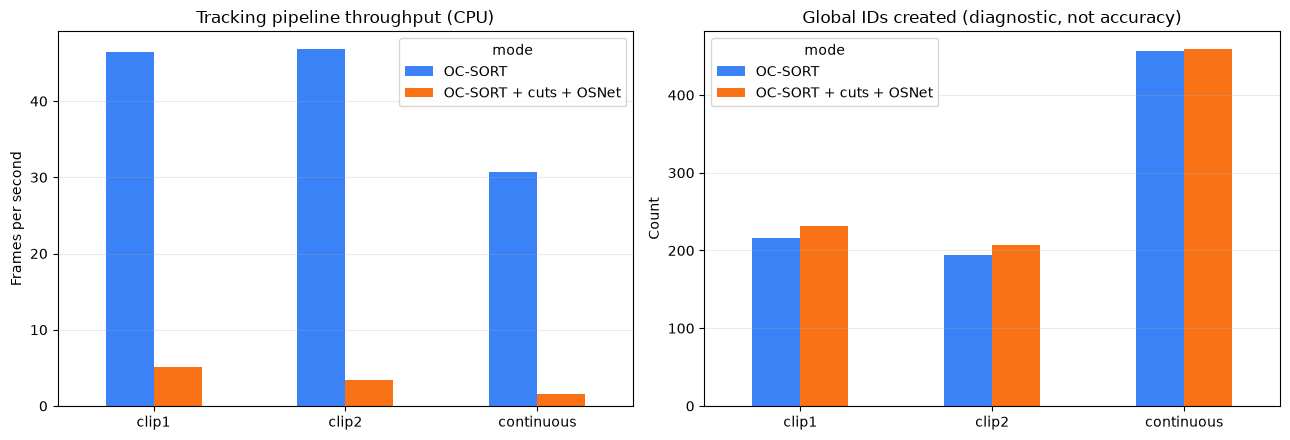

Saved: D:\Bunker\BaseCamp\SceneCut Aware tracking\outputs\comparisons\yolo11_custom_clips\yolo11_three_clip_summary.png


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

results.pivot(index="clip", columns="mode", values="tracker_pipeline_fps").plot(
    kind="bar", ax=axes[0], rot=0, color=["#3b82f6", "#f97316"]
)
axes[0].set_title("Tracking pipeline throughput (CPU)")
axes[0].set_ylabel("Frames per second")
axes[0].set_xlabel("")
axes[0].grid(axis="y", alpha=0.25)

results.pivot(index="clip", columns="mode", values="global_ids").plot(
    kind="bar", ax=axes[1], rot=0, color=["#3b82f6", "#f97316"]
)
axes[1].set_title("Global IDs created (diagnostic, not accuracy)")
axes[1].set_ylabel("Count")
axes[1].set_xlabel("")
axes[1].grid(axis="y", alpha=0.25)

plt.tight_layout()
plot_path = PLOT_DIR / "yolo11_three_clip_summary.png"
plt.savefig(plot_path, dpi=160, bbox_inches="tight")
plt.show()
print(f"Saved: {plot_path}")

## Scene-cut and ReID event summary

In [5]:
events = pd.DataFrame(event_rows)
display(events.round(3))

,clip,cut_frames,accepted_recoveries,mean_similarity
0,clip1,"[170, 185, 474, 489, 517, 648, 693, 822, 837, ...",25,0.847
1,clip2,"[203, 220, 238, 359, 377, 394, 409, 424, 439, ...",108,0.864
2,continuous,"[44, 59, 76, 806, 822, 837]",40,0.870


## Six annotated result videos

Baseline is on the left. Cut-aware OC-SORT + OSNet is on the right. These are
the browser-compatible H.264 copies; the original full-length OpenCV outputs
are preserved beside them.

In [6]:
def relative_video_path(clip_name: str, mode: str) -> str:
    if mode == "baseline":
        folder = f"{clip_name}_yolo11n_ocsort_cpu"
    else:
        folder = f"{clip_name}_yolo11n_ocsort_scenecut_osnet_cpu"
    return f"../outputs/{mode}/{folder}/annotated_{mode}_h264.mp4"

cards = []
for clip_name in CLIPS:
    left = relative_video_path(clip_name, "baseline")
    right = relative_video_path(clip_name, "improved")
    cards.append(
        f"<h3 style='margin-top:24px'>{clip_name}</h3>"
        "<div style='display:grid;grid-template-columns:1fr 1fr;gap:16px'>"
        f"<div><b>YOLO11 + OC-SORT</b><video controls preload='metadata' style='width:100%;margin-top:8px'><source src='{left}' type='video/mp4'></video></div>"
        f"<div><b>YOLO11 + OC-SORT + scene cut + OSNet</b><video controls preload='metadata' style='width:100%;margin-top:8px'><source src='{right}' type='video/mp4'></video></div>"
        "</div>"
    )
display(HTML("".join(cards)))

## Honest conclusion

YOLO11 produces visibly stronger person proposals on these custom clips than the
earlier YOLOX-S setup, especially for small players. However, this notebook does
not claim a numerical accuracy improvement because these clips do not include
identity annotations. The valid conclusions are:

- all three inputs were processed at their original full duration;
- baseline and improved modes used identical YOLO11 detection caches;
- hard cuts reset OC-SORT motion state while OSNet identity memory survived;
- cross-cut matches were accepted only above the configured conservative threshold;
- HOTA/IDF1/MOTA and true ID-switch comparisons require MOT identity ground truth.